In [2]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import os
import torch.nn.init as init

class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.k1 = nn.Parameter(torch.Tensor(1))
        self.k2 = nn.Parameter(torch.Tensor(1))
        self.k3 = nn.Parameter(torch.Tensor(1))
        self.kd = nn.Parameter(torch.Tensor(1))
        init.constant_(self.k1, 0.001)
        init.constant_(self.k2, 0.02735345)
        init.constant_(self.k3, 0.50865889)
        init.constant_(self.kd, 10.0)

    def forward(self, L, I, I0, Imax):
        x1 = torch.sqrt((self.k2*I+1)*(self.k2*I+1)+ 8 * L * (self.k2*self.k2*self.k3*I*I + self.k1)+1e-9)
        P1 = (Imax * ((L / 2 + 1e-9) * ((x1 -  (self.k2*I+1)+ 1e-9) / (x1 +  (self.k2*I+1)) +1e-9) * (self.kd + 1e-9) / (1 + (L / 2 + 1e-9) * ((x1 -  (self.k2*I+1)+ 1e-9) / (x1 +  (self.k2*I+1)+1e-9) + 1e-9) *(self.kd + 1e-9))) + I0)
        return P1

# 初始化模型
model = MyModel()

# 遍历文件夹中的csv文件，将所有的数据合并到一起
folder_path = r'E:\Desktop\data\data1'
data = []
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        # 读取csv文件
        df = pd.read_csv(os.path.join(folder_path, filename))
        data.append(df)

# 合并所有的数据
data_all = pd.concat(data)

# 提取你需要的列
L_all = torch.tensor(data_all['LBD'].dropna().values, dtype=torch.float32)
I_all = torch.tensor(data_all['inducer'].dropna().values, dtype=torch.float32)
I0_all = torch.tensor(0.059199421, dtype=torch.float32)
Imax_all = torch.tensor(13.60910816, dtype=torch.float32)
y_all = torch.tensor(data_all['RPU'].dropna().values, dtype=torch.float32)

# 训练模型得到k1, k2, k3
optimizer_all = torch.optim.Adam([model.k1, model.k2, model.k3], lr=0.001)
for _ in range(100000):  # 迭代1000次
    optimizer_all.zero_grad()
    output_all = model(L_all, I_all, I0_all, Imax_all)
    loss_all = nn.MSELoss()(output_all, y_all)
    loss_all.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
    optimizer_all.step()
print(f'Iteration {_}, Loss {loss_all.item()}')
    

print(f'k1={model.k1.item()}, k2={model.k2.item()}, k3={model.k3.item()}')

# 对每个文件单独拟合kd
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        # 读取csv文件
        df = pd.read_csv(os.path.join(folder_path, filename))
        # 提取你需要的列
        L = torch.tensor(df['LBD'].dropna().values, dtype=torch.float32)
        I = torch.tensor(df['inducer'].dropna().values, dtype=torch.float32)
        I0 = torch.tensor(0.059199421, dtype=torch.float32)
        Imax = torch.tensor(13.60910816, dtype=torch.float32)
        y = torch.tensor(df['RPU'].dropna().values, dtype=torch.float32)

        # 训练模型
        optimizer_kd = torch.optim.Adam([model.kd], lr=0.001)
        for _ in range(150000):  
            optimizer_kd.zero_grad()
            output = model(L, I, I0, Imax)
            loss = nn.MSELoss()(output, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            optimizer_kd.step()
        print(f'File {filename}, Iteration {_}, Loss {loss.item()}')
            
        
        print(f'For file {filename}, kd={model.kd.item()}')

Iteration 99999, Loss 32.466129302978516
k1=0.0009180880151689053, k2=0.010791292414069176, k3=2.22281813621521
File 335_without1st.csv, Iteration 149999, Loss 34.169677734375
For file 335_without1st.csv, kd=24.62809181213379
File 336.csv, Iteration 149999, Loss 69.95211791992188
For file 336.csv, kd=166.97708129882812
File 337_without1st.csv, Iteration 149999, Loss 14.59760856628418
For file 337_without1st.csv, kd=16.190351486206055
File 338_without1st.csv, Iteration 149999, Loss 13.089885711669922
For file 338_without1st.csv, kd=3.2396240234375
File 339_without1st.csv, Iteration 149999, Loss 50.80990219116211
For file 339_without1st.csv, kd=8.511429786682129
File 340_without1st.csv, Iteration 149999, Loss 21.406021118164062
For file 340_without1st.csv, kd=17.01329803466797
File 341_without1st.csv, Iteration 149999, Loss 60.721370697021484
For file 341_without1st.csv, kd=6.134970664978027
File 342_without1st.csv, Iteration 149999, Loss 6.636512279510498
For file 342_without1st.csv, kd

In [1]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import os
import torch.nn.init as init

class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.k1 = nn.Parameter(torch.Tensor(1))
        self.k2 = nn.Parameter(torch.Tensor(1))
        self.k3 = nn.Parameter(torch.Tensor(1))
        self.kd = nn.Parameter(torch.Tensor(1))
        init.constant_(self.k1, 0.001)
        init.constant_(self.k2, 0.02735345)
        init.constant_(self.k3, 0.50865889)
        init.constant_(self.kd, 10.0)

    def forward(self, L, I, I0, Imax):
        x1 = torch.sqrt((self.k2*I+1)*(self.k2*I+1)+ 8 * L * (self.k2*self.k2*self.k3*I*I + self.k1)+1e-9)
        P1 = (Imax * ((L / 2 + 1e-9) * ((x1 -  (self.k2*I+1)+ 1e-9) / (x1 +  (self.k2*I+1)) +1e-9) * (self.kd + 1e-9) / (1 + (L / 2 + 1e-9) * ((x1 -  (self.k2*I+1)+ 1e-9) / (x1 +  (self.k2*I+1)+1e-9) + 1e-9) *(self.kd + 1e-9))) + I0)
        return P1

# 初始化模型
model = MyModel()

# 遍历文件夹中的csv文件，将所有的数据合并到一起
folder_path = r'E:\Desktop\data\data1' 
data = []
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        # 读取csv文件
        df = pd.read_csv(os.path.join(folder_path, filename))
        data.append(df)

# 合并所有的数据
data_all = pd.concat(data)

# 提取你需要的列
L_all = torch.tensor(data_all['LBD'].dropna().values, dtype=torch.float32)
I_all = torch.tensor(data_all['inducer'].dropna().values, dtype=torch.float32)
I0_all = torch.tensor(0.049378964, dtype=torch.float32)
Imax_all = torch.tensor(13.60910816, dtype=torch.float32)
y_all = torch.tensor(data_all['RPU'].dropna().values, dtype=torch.float32)

# 训练模型得到kd
optimizer_kd = torch.optim.Adam([model.kd], lr=0.001)
for _ in range(100000):  # 迭代1000次
    optimizer_kd.zero_grad()
    output_kd = model(L_all, I_all, I0_all, Imax_all)
    loss_kd = nn.MSELoss()(output_kd, y_all)
    loss_kd.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
    optimizer_kd.step()
print(f'Iteration {_}, Loss {loss_kd.item()}')
print(f'For file {filename}, kd={model.kd.item()}')    


# 对每个文件单独拟合kd
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        # 读取csv文件
        df = pd.read_csv(os.path.join(folder_path, filename))
        # 提取你需要的列
        L = torch.tensor(df['LBD'].dropna().values, dtype=torch.float32)
        I = torch.tensor(df['inducer'].dropna().values, dtype=torch.float32)
        I0 = torch.tensor(0.049378964, dtype=torch.float32)
        Imax = torch.tensor(13.60910816, dtype=torch.float32)
        y = torch.tensor(df['RPU'].dropna().values, dtype=torch.float32)

        # 训练模型
        optimizer_all = torch.optim.Adam([model.k1, model.k2, model.k3], lr=0.001)
        for _ in range(150000):  
            optimizer_all.zero_grad()
            output_all = model(L, I, I0, Imax)
            loss_all = nn.MSELoss()(output_all, y)
            loss_all.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            optimizer_all.step()
        print(f'File {filename}, Iteration {_}, Loss {loss_all.item()}')
        print(f'k1={model.k1.item()}, k2={model.k2.item()}, k3={model.k3.item()}')    
        
        

Iteration 99999, Loss 32.55849075317383
For file 389.csv, kd=13.448269844055176
File 335_without1st.csv, Iteration 149999, Loss 34.5101203918457
k1=0.002192145213484764, k2=0.001947093871422112, k3=37.80547332763672
File 336.csv, Iteration 149999, Loss 79.10521697998047
k1=0.002754208631813526, k2=0.008723023347556591, k3=180.74671936035156
File 337_without1st.csv, Iteration 149999, Loss 13.206100463867188
k1=0.0003159788902848959, k2=0.0008430902380496264, k3=169.18287658691406
File 338_without1st.csv, Iteration 149999, Loss 13.367345809936523
k1=0.0003196574398316443, k2=-8.243374759331346e-05, k3=120.37425994873047
File 339_without1st.csv, Iteration 149999, Loss 47.716552734375
k1=4.708061169367284e-06, k2=-0.00034879663144238293, k3=129.15333557128906
File 340_without1st.csv, Iteration 149999, Loss nan
k1=nan, k2=nan, k3=nan
File 341_without1st.csv, Iteration 149999, Loss nan
k1=nan, k2=nan, k3=nan
File 342_without1st.csv, Iteration 149999, Loss nan
k1=nan, k2=nan, k3=nan
File 343_

In [8]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import os
import torch.nn.init as init

class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.k1 = nn.Parameter(torch.Tensor(1))
        self.k2 = nn.Parameter(torch.Tensor(1))
        self.k3 = nn.Parameter(torch.Tensor(1))
        self.kx1 = nn.Parameter(torch.Tensor(1))
        self.kx2 = nn.Parameter(torch.Tensor(1))
        self.kd = nn.Parameter(torch.Tensor(1))
        init.constant_(self.k1, 0.000748235207890)
        init.constant_(self.k2, 0.456403423356008)
        init.constant_(self.k3, 0.023932304995422)
        init.constant_(self.kx1, 0.229368425090218)
        init.constant_(self.kx2, 0.000046218624817)
        init.constant_(self.kd, 10.0)

  
    def forward(self, L, I, I0, Imax):
        # 确保所有参数为正值
        k1 = torch.abs(self.k1)
        k2 = torch.abs(self.k2)
        k3 = torch.abs(self.k3)
        kx1 = torch.abs(self.kx1)
        kx2 = torch.abs(self.kx2)
        kd = torch.abs(self.kd)
        kx2 = torch.clamp(torch.abs(self.kx2), min=0.001)

        x1 = torch.sqrt((k2 * I + kx1 + kx2 * k2 * I + 1) ** 2 + 
                        8 * L * (k2 ** 2 * k3 * I ** 2 + 
                                 k1 + k1 * kx1 ** 2 + 
                                 k3 * k2 ** 2 * kx2 ** 2 * I ** 2))
        P1 = (Imax * ((L / 2) * ((x1 - (k2 * I + kx1 + kx2 * k2 * I + 1)) / 
               (x1 + (k2 * I + kx1 + kx2 * k2 * I + 1))) * kd / 
               (1 + (L / 2) * ((x1 - (k2 * I + kx1 + kx2 * k2 * I + 1)) / 
               (x1 + (k2 * I + kx1 + kx2 * k2 * I + 1))) * kd)) + I0)
        return P1

# 初始化模型
model = MyModel()

# 遍历文件夹中的csv文件，将所有的数据合并到一起
folder_path = 'E:\Desktop\mamm\MR'
data = []
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        # 读取csv文件
        df = pd.read_csv(os.path.join(folder_path, filename))
        data.append(df)

# 合并所有的数据
data_all = pd.concat(data)

# 提取需要的列
L_all = torch.tensor(data_all['LBD'].dropna().values, dtype=torch.float32)
I_all = torch.tensor(data_all['inducer'].dropna().values, dtype=torch.float32)
I0_all = torch.tensor(0.062385854, dtype=torch.float32)
Imax_all = torch.tensor(13.60910816, dtype=torch.float32)
y_all = torch.tensor(data_all['RPU'].dropna().values, dtype=torch.float32)

# 训练模型得到k1, k2, k3
optimizer_all = torch.optim.Adam([model.k1, model.k2, model.k3, model.kx1, model.kx2], lr=0.001)
for _ in range(100000):  # 迭代100000次
    optimizer_all.zero_grad()
    output_all = model(L_all, I_all, I0_all, Imax_all)
    loss_all = nn.MSELoss()(output_all, y_all)
    loss_all.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
    optimizer_all.step()
print(f'Iteration {_}, Loss {loss_all.item()}')

print(f'k1={torch.abs(model.k1).item()}, k2={torch.abs(model.k2).item()}, k3={torch.abs(model.k3).item()}, kx1={torch.abs(model.kx1).item()}, kx2={torch.abs(model.kx2).item()}')

# 对每个文件单独拟合kd
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        # 读取csv文件
        df = pd.read_csv(os.path.join(folder_path, filename))
        # 提取你需要的列
        L = torch.tensor(df['LBD'].dropna().values, dtype=torch.float32)
        I = torch.tensor(df['inducer'].dropna().values, dtype=torch.float32)
        I0 = torch.tensor(0.062385854, dtype=torch.float32)
        Imax = torch.tensor(13.60910816, dtype=torch.float32)
        y = torch.tensor(df['RPU'].dropna().values, dtype=torch.float32)

        # 训练模型
        optimizer_kd = torch.optim.Adam([model.kd], lr=0.001)
        for _ in range(150000):  
            optimizer_kd.zero_grad()
            output = model(L, I, I0, Imax)
            loss = nn.MSELoss()(output, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            optimizer_kd.step()
        print(f'File {filename}, Iteration {_}, Loss {loss.item()}')
        
        print(f'For file {filename}, kd={torch.abs(model.kd).item()}')


Iteration 99999, Loss 0.6480774283409119
k1=0.0009260723018087447, k2=0.07457327842712402, k3=1.2460715770721436, kx1=1.013840675354004, kx2=4.621862535714172e-05
File 414.csv, Iteration 149999, Loss 0.7627090215682983
For file 414.csv, kd=20.277633666992188
File 415.csv, Iteration 149999, Loss 0.008509106002748013
For file 415.csv, kd=2.8982932567596436


In [9]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import os
import torch.nn.init as init

class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.k1 = nn.Parameter(torch.Tensor(1))
        self.k2 = nn.Parameter(torch.Tensor(1))
        self.k3 = nn.Parameter(torch.Tensor(1))
        self.kx1 = nn.Parameter(torch.Tensor(1))
        self.kx2 = nn.Parameter(torch.Tensor(1))
        self.kd = nn.Parameter(torch.Tensor(1))
        init.constant_(self.k1, 4.67083E-05)
        init.constant_(self.k2, 0.31018734)
        init.constant_(self.k3, 0.650004327)
        init.constant_(self.kd, 10.0)

  
    def forward(self, L, I, I0, Imax):
        # 确保所有参数为正值
        k1 = torch.abs(self.k1)
        k2 = torch.abs(self.k2)
        k3 = torch.abs(self.k3)
        kd = torch.abs(self.kd)
        kx2 = torch.clamp(torch.abs(self.kx2), min=0.001)

        x1 = torch.sqrt((k2 * I + 1) ** 2 + 
                        8 * L * (k2 ** 2 * k3 * I ** 2 + 
                                 k1 ))
        P1 = (Imax * ((L / 2) * ((x1 - (k2 * I +  1)) / 
               (x1 + (k2 * I + 1))) * kd / 
               (1 + (L / 2) * ((x1 - (k2 * I +  1)) / 
               (x1 + (k2 * I +  1))) * kd)) + I0)
        return P1

# 初始化模型
model = MyModel()

# 遍历文件夹中的csv文件，将所有的数据合并到一起
folder_path = 'E:\Desktop\mamm\\RpaR'
data = []
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        # 读取csv文件
        df = pd.read_csv(os.path.join(folder_path, filename))
        data.append(df)

# 合并所有的数据
data_all = pd.concat(data)

# 提取需要的列
L_all = torch.tensor(data_all['LBD'].dropna().values, dtype=torch.float32)
I_all = torch.tensor(data_all['inducer'].dropna().values, dtype=torch.float32)
I0_all = torch.tensor(0.131326427, dtype=torch.float32)
Imax_all = torch.tensor(13.60910816, dtype=torch.float32)
y_all = torch.tensor(data_all['RPU'].dropna().values, dtype=torch.float32)

# 训练模型得到k1, k2, k3
optimizer_all = torch.optim.Adam([model.k1, model.k2, model.k3], lr=0.001)
for _ in range(100000):  # 迭代100000次
    optimizer_all.zero_grad()
    output_all = model(L_all, I_all, I0_all, Imax_all)
    loss_all = nn.MSELoss()(output_all, y_all)
    loss_all.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
    optimizer_all.step()
print(f'Iteration {_}, Loss {loss_all.item()}')

print(f'k1={torch.abs(model.k1).item()}, k2={torch.abs(model.k2).item()}, k3={torch.abs(model.k3).item()}')

# 对每个文件单独拟合kd
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        # 读取csv文件
        df = pd.read_csv(os.path.join(folder_path, filename))
        # 提取你需要的列
        L = torch.tensor(df['LBD'].dropna().values, dtype=torch.float32)
        I = torch.tensor(df['inducer'].dropna().values, dtype=torch.float32)
        I0 = torch.tensor(0.131326427, dtype=torch.float32)
        Imax = torch.tensor(13.60910816, dtype=torch.float32)
        y = torch.tensor(df['RPU'].dropna().values, dtype=torch.float32)

        # 训练模型
        optimizer_kd = torch.optim.Adam([model.kd], lr=0.001)
        for _ in range(150000):  
            optimizer_kd.zero_grad()
            output = model(L, I, I0, Imax)
            loss = nn.MSELoss()(output, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            optimizer_kd.step()
        print(f'File {filename}, Iteration {_}, Loss {loss.item()}')
        
        print(f'For file {filename}, kd={torch.abs(model.kd).item()}')


Iteration 99999, Loss 2.7322537899017334
k1=0.00042178892181254923, k2=0.0015821732813492417, k3=80.392333984375
File 406.csv, Iteration 149999, Loss 2.5248754024505615
For file 406.csv, kd=13.811304092407227
File 407.csv, Iteration 149999, Loss 2.708733558654785
For file 407.csv, kd=11.81407356262207


In [6]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import os
import torch.nn.init as init

class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.k1 = nn.Parameter(torch.Tensor(1))
        self.k2 = nn.Parameter(torch.Tensor(1))
        self.k3 = nn.Parameter(torch.Tensor(1))
        self.kx1 = nn.Parameter(torch.Tensor(1))
        self.kx2 = nn.Parameter(torch.Tensor(1))
        self.kd = nn.Parameter(torch.Tensor(1))
        init.constant_(self.k1, 4.67083E-05)
        init.constant_(self.k2, 5.31018734)
        init.constant_(self.k3, 0.650004327)
        init.constant_(self.kx1, 1.086833596)
        init.constant_(self.kx2, 4.230793476)
        init.constant_(self.kd, 10.0)

    def forward(self, L, I, I0, Imax):
        # 确保所有参数为正值
        k1 = torch.abs(self.k1)
        k2 = torch.abs(self.k2)
        k3 = torch.abs(self.k3)
        kx1 = torch.abs(self.kx1)
        kx2 = torch.abs(self.kx2)
        kd = torch.abs(self.kd)

        x1 = torch.sqrt((k2 * I + kx1 + kx2 * k2 * I + 1) ** 2 + 
                        8 * L * (k2 ** 2 * k3 * I ** 2 + 
                                 k1 + k1 * kx1 ** 2 + 
                                 k3 * k2 ** 2 * kx2 ** 2 * I ** 2))
        P1 = (Imax * ((L / 2) * ((x1 - (k2 * I + kx1 + kx2 * k2 * I + 1)) / 
               (x1 + (k2 * I + kx1 + kx2 * k2 * I + 1))) * kd / 
               (1 + (L / 2) * ((x1 - (k2 * I + kx1 + kx2 * k2 * I + 1)) / 
               (x1 + (k2 * I + kx1 + kx2 * k2 * I + 1))) * kd)) + I0)
        return P1

# 初始化模型
model = MyModel()

# 遍历文件夹中的csv文件，将所有的数据合并到一起
folder_path = 'E:\\Desktop\\PurR'
data = []
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        # 读取csv文件
        df = pd.read_csv(os.path.join(folder_path, filename))
        data.append(df)

# 合并所有的数据
data_all = pd.concat(data)

# 提取需要的列
L_all = torch.tensor(data_all['LBD'].dropna().values, dtype=torch.float32)
I_all = torch.tensor(data_all['inducer'].dropna().values, dtype=torch.float32)
I0_all = torch.tensor(0.049378964, dtype=torch.float32)
Imax_all = torch.tensor(13.60910816, dtype=torch.float32)
y_all = torch.tensor(data_all['RPU'].dropna().values, dtype=torch.float32)

# 训练模型得到k1, k2, k3
optimizer_kd = torch.optim.Adam([model.kd], lr=0.001)
for _ in range(100000):  # 迭代100000次
    optimizer_kd.zero_grad()
    output_kd= model(L_all, I_all, I0_all, Imax_all)
    loss_kd = nn.MSELoss()(output_kd, y_all)
    loss_kd.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
    optimizer_kd.step()
print(f'Iteration {_}, Loss {loss_kd.item()}')

print(f'For file {filename}, kd={torch.abs(model.kd).item()}')

# 对每个文件单独拟合kd
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        # 读取csv文件
        df = pd.read_csv(os.path.join(folder_path, filename))
        # 提取你需要的列
        L = torch.tensor(df['LBD'].dropna().values, dtype=torch.float32)
        I = torch.tensor(df['inducer'].dropna().values, dtype=torch.float32)
        I0 = torch.tensor(0.049378964, dtype=torch.float32)
        Imax = torch.tensor(13.60910816,dtype=torch.float32)
        y = torch.tensor(df['RPU'].dropna().values, dtype=torch.float32)

        # 训练模型
        optimizer_all = torch.optim.Adam([model.k1, model.k2, model.k3, model.kx1, model.kx2], lr=0.001)
        for _ in range(150000):  
            optimizer_all.zero_grad()
            output_all = model(L, I, I0, Imax)
            loss_all = nn.MSELoss()(output_all, y)
            loss_all.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            optimizer_all.step()
        print(f'File {filename}, Iteration {_}, Loss {loss_all.item()}')
        print(f'k1={torch.abs(model.k1).item()}, k2={torch.abs(model.k2).item()}, k3={torch.abs(model.k3).item()}, kx1={torch.abs(model.kx1).item()}, kx2={torch.abs(model.kx2).item()}')

        


Iteration 99999, Loss 5.138452053070068
For file 408.csv, kd=0.3218388557434082
File 406.csv, Iteration 149999, Loss 5.875372409820557
k1=0.018417684361338615, k2=0.003929343074560165, k3=142.83682250976562, kx1=4.860310077667236, kx2=138.0186004638672
File 408.csv, Iteration 149999, Loss 0.028780508786439896
k1=0.012917980551719666, k2=9.088483784580603e-05, k3=59.549598693847656, kx1=84.91988372802734, kx2=55.61396408081055


In [7]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import os
import torch.nn.init as init

class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        # 定义未约束的 log 参数
        self.log_k1 = nn.Parameter(torch.tensor(-6.9078))  # e^-6.9078 ≈ 0.001
        self.log_k2 = nn.Parameter(torch.tensor(-3.6076))  # e^-3.6076 ≈ 0.02735345
        self.log_k3 = nn.Parameter(torch.tensor(-0.6768))  # e^-0.6768 ≈ 0.50865889
        self.log_kd = nn.Parameter(torch.tensor(2.3026))   # e^2.3026 ≈ 10.0

    def forward(self, L, I, I0, Imax):
        # 使用指数函数确保每个参数为正值
        k1 = torch.exp(self.log_k1)
        k2 = torch.exp(self.log_k2)
        k3 = torch.exp(self.log_k3)
        kd = torch.exp(self.log_kd)

        # 使用转换后的正值参数进行计算
        x1 = torch.sqrt((k2 * I + + 1) ** 2 + 
                        8 * L * (k2 ** 2 * k3 * I ** 2 + 
                        k1  
                        ))
        P1 = (Imax * ((L / 2) * ((x1 - (k2 * I  + 1)) / 
               (x1 + (k2 * I  + 1))) * kd / 
               (1 + (L / 2) * ((x1 - (k2 * I + 1)) / 
               (x1 + (k2 * I + 1))) * kd)) + I0)
        return P1

# 初始化模型
model = MyModel()

# 遍历文件夹中的 csv 文件，将所有的数据合并到一起
folder_path = 'E:\\Desktop\\mamm\RpaR'
data = []
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        # 读取 csv 文件
        df = pd.read_csv(os.path.join(folder_path, filename))
        data.append(df)

# 合并所有的数据
data_all = pd.concat(data)

# 提取你需要的列
L_all = torch.tensor(data_all['LBD'].dropna().values, dtype=torch.float32)
I_all = torch.tensor(data_all['inducer'].dropna().values, dtype=torch.float32)
I0_all = torch.tensor(0.049378964, dtype=torch.float32)
Imax_all = torch.tensor(13.60910816, dtype=torch.float32)
y_all = torch.tensor(data_all['RPU'].dropna().values, dtype=torch.float32)

# 训练模型得到 k1, k2, k3
optimizer_all = torch.optim.Adam([model.log_k1, model.log_k2, model.log_k3], lr=0.001)
for i in range(100000):  # 迭代100000次
    optimizer_all.zero_grad()
    output_all = model(L_all, I_all, I0_all, Imax_all)
    loss_all = nn.MSELoss()(output_all, y_all)
    loss_all.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
    optimizer_all.step()
    if i % 100000 == 0:  # 每1000次打印一次损失
        print(f'Iteration {i}, Loss {loss_all.item()}')

print(f'k1={torch.exp(model.log_k1).item()}, k2={torch.exp(model.log_k2).item()}, k3={torch.exp(model.log_k3).item()}')

# 对每个文件单独拟合 kd
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        # 读取 csv 文件
        df = pd.read_csv(os.path.join(folder_path, filename))
        # 提取你需要的列
        L = torch.tensor(df['LBD'].dropna().values, dtype=torch.float32)
        I = torch.tensor(df['inducer'].dropna().values, dtype=torch.float32)
        I0 = torch.tensor(0.049378964, dtype=torch.float32)
        Imax = torch.tensor(13.609108165, dtype=torch.float32)
        y = torch.tensor(df['RPU'].dropna().values, dtype=torch.float32)

        # 训练模型
        optimizer_kd = torch.optim.Adam([model.log_kd], lr=0.001)
        for i in range(150000):  
            optimizer_kd.zero_grad()
            output = model(L, I, I0, Imax)
            loss = nn.MSELoss()(output, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            optimizer_kd.step()
            if i % 1000 == 0:  # 每1000次打印一次损失
                print(f'File {filename}, Iteration {i}, Loss {loss.item()}')
                
        print(f'For file {filename}, kd={torch.exp(model.log_kd).item()}')


Iteration 0, Loss 5.215233325958252
k1=0.000539633387234062, k2=6.833666787997572e-08, k3=45085048832.0
File 406.csv, Iteration 0, Loss 2.5990262031555176
File 406.csv, Iteration 1000, Loss 2.479001522064209
File 406.csv, Iteration 2000, Loss 2.479001522064209
File 406.csv, Iteration 3000, Loss 2.47900128364563
File 406.csv, Iteration 4000, Loss 2.479001522064209
File 406.csv, Iteration 5000, Loss 2.47900128364563
File 406.csv, Iteration 6000, Loss 2.479001522064209
File 406.csv, Iteration 7000, Loss 2.479001760482788
File 406.csv, Iteration 8000, Loss 2.479001760482788
File 406.csv, Iteration 9000, Loss 2.479001760482788
File 406.csv, Iteration 10000, Loss 2.479001760482788
File 406.csv, Iteration 11000, Loss 2.479001760482788
File 406.csv, Iteration 12000, Loss 2.479001760482788
File 406.csv, Iteration 13000, Loss 2.479001522064209
File 406.csv, Iteration 14000, Loss 2.479001522064209
File 406.csv, Iteration 15000, Loss 2.479001522064209
File 406.csv, Iteration 16000, Loss 2.47900128

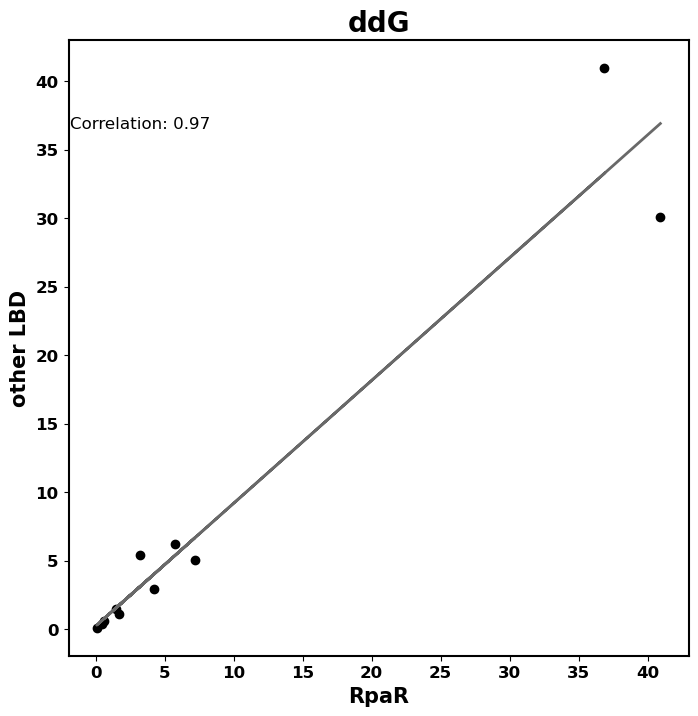

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 读取CSV文件
data1 = pd.read_csv('E:\Desktop\DBD_independence1.csv')
data2 = pd.read_csv('E:\Desktop\DBD_independence2.csv')

# 按照ID排序数据
sorted_data1 = data1.sort_values('ID')
sorted_data2 = data2.sort_values('ID')

# 提取预测值和实际值
prediction1 = sorted_data1['other']
prediction2 = sorted_data2['LasR']
actual_values1 = sorted_data1['RpaR']
actual_values2 = sorted_data2['RpaR']

# 创建并拟合线性回归模型
regressor1 = LinearRegression()
regressor1.fit(prediction1.values.reshape(-1, 1), actual_values1)

regressor2 = LinearRegression()
regressor2.fit(prediction2.values.reshape(-1, 1), actual_values2)

# 设置正方形画布
plt.figure(figsize=(8, 8))

# 绘制散点图和相关性直线，使用黑色和灰色
plt.scatter(prediction1, actual_values1, color='black', marker='o')  # 黑色点
#plt.scatter(prediction2, actual_values2, label='LasR', color='gray', marker='^')   # 灰色点
plt.plot(prediction1, regressor1.predict(prediction1.values.reshape(-1, 1)), color='dimgray', linewidth=2)  # 深灰色线
#plt.plot(prediction2, regressor2.predict(prediction2.values.reshape(-1, 1)), color='lightgray', linewidth=2)  # 浅灰色线

# 设置轴标签、标题、图例
plt.xlabel('RpaR', fontweight='bold', fontsize=15)
plt.ylabel('other LBD', fontweight='bold', fontsize=15)
plt.title('ddG', fontweight='bold', fontsize=20)
#plt.legend()

# 设置坐标轴加粗
plt.gca().spines['top'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_linewidth(1.5)
plt.gca().spines['left'].set_linewidth(1.5)
plt.gca().spines['right'].set_linewidth(1.5)

# 设置刻度大小和粗细
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# 设置相关系数
corr1 = np.corrcoef(prediction1, actual_values1)[0, 1]
#corr2 = np.corrcoef(prediction2, actual_values2)[0, 1]
plt.text(plt.xlim()[0] + 0.1, plt.ylim()[1] - 6.5, f'Correlation: {corr1:.2f}', fontsize=12)
#plt.text(plt.xlim()[0] + 0.1, plt.ylim()[1] - 9, f'Correlation(LasR): {corr2:.2f}', fontsize=12)
plt.savefig("E:\Desktop\ddG.svg",format="svg")
# 显示图形
plt.show()